In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
train['Heart Disease'] = train['Heart Disease'].map({'Presence': 0, 'Absence': 1})

In [5]:
matrix = train.corr()
print(matrix)

                               id       Age       Sex  Chest pain type  \
id                       1.000000  0.000975 -0.000784        -0.001332   
Age                      0.000975  1.000000  0.088397         0.109453   
Sex                     -0.000784  0.088397  1.000000         0.195893   
Chest pain type         -0.001332  0.109453  0.195893         1.000000   
BP                      -0.001264 -0.003960 -0.003355        -0.003587   
Cholesterol             -0.001692  0.019485  0.038373         0.045463   
FBS over 120            -0.000647  0.013354  0.020333         0.023036   
EKG results              0.002151  0.057431  0.093590         0.120907   
Max HR                  -0.000089 -0.097542 -0.176186        -0.221806   
Exercise angina          0.000923  0.110153  0.192705         0.246211   
ST depression            0.000973  0.103064  0.181093         0.240228   
Slope of ST             -0.000114  0.096337  0.169854         0.233849   
Number of vessels fluro -0.000273  0.1

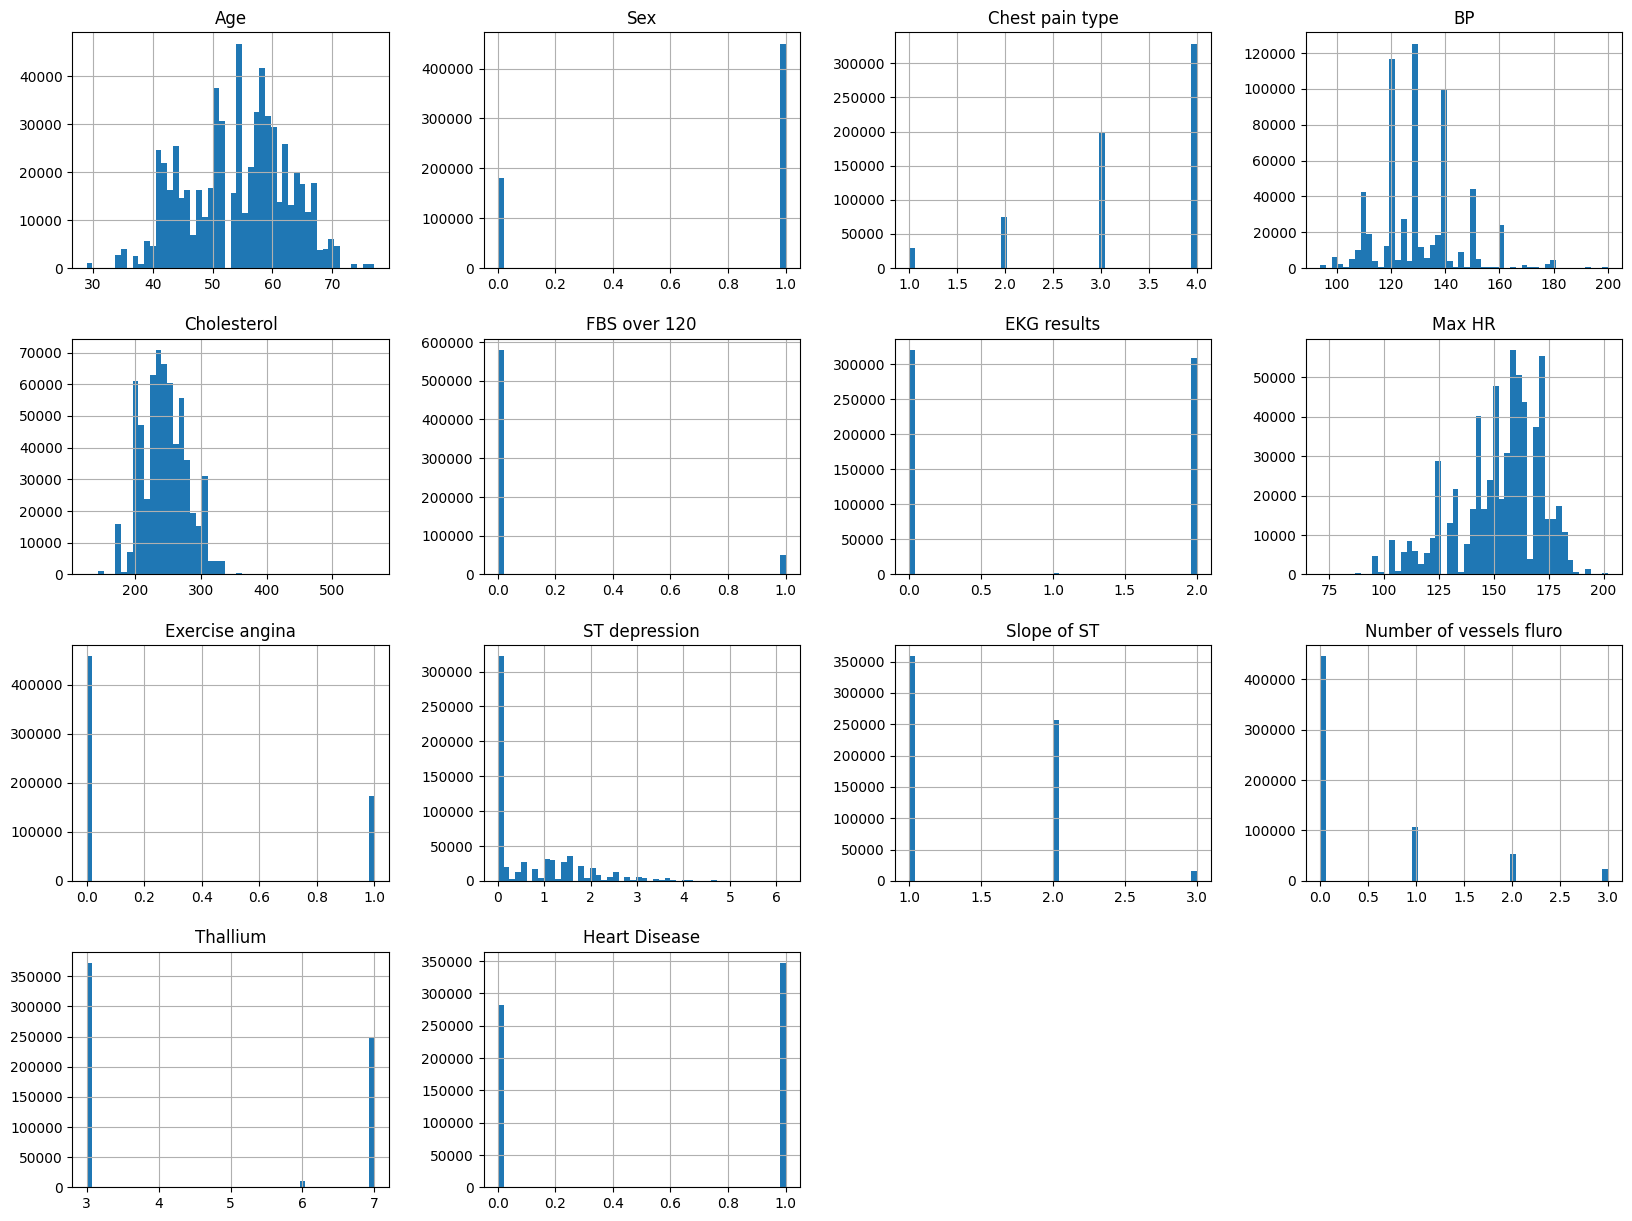

In [6]:
train = train.drop('id', axis='columns')
train.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
matrix["Age"].sort_values(ascending=False)


Age                        1.000000
Thallium                   0.150124
Exercise angina            0.110153
Chest pain type            0.109453
ST depression              0.103064
Number of vessels fluro    0.102758
Slope of ST                0.096337
Sex                        0.088397
EKG results                0.057431
Cholesterol                0.019485
FBS over 120               0.013354
id                         0.000975
BP                        -0.003960
Max HR                    -0.097542
Heart Disease             -0.212091
Name: Age, dtype: float64

In [8]:
train['exercise_angina_by_age'] = train['Exercise angina'] / train['Sex']


In [9]:
train['cholesterol_blood_pressure'] = train['Cholesterol'] / train['BP']

In [10]:
matrix = train.corr()
matrix['Age'].sort_values(ascending=False)

Age                           1.000000
Thallium                      0.150124
Exercise angina               0.110153
Chest pain type               0.109453
ST depression                 0.103064
Number of vessels fluro       0.102758
exercise_angina_by_age        0.102483
Slope of ST                   0.096337
Sex                           0.088397
EKG results                   0.057431
Cholesterol                   0.019485
cholesterol_blood_pressure    0.017142
FBS over 120                  0.013354
BP                           -0.003960
Max HR                       -0.097542
Heart Disease                -0.212091
Name: Age, dtype: float64

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Age                         630000 non-null  int64  
 1   Sex                         630000 non-null  int64  
 2   Chest pain type             630000 non-null  int64  
 3   BP                          630000 non-null  int64  
 4   Cholesterol                 630000 non-null  int64  
 5   FBS over 120                630000 non-null  int64  
 6   EKG results                 630000 non-null  int64  
 7   Max HR                      630000 non-null  int64  
 8   Exercise angina             630000 non-null  int64  
 9   ST depression               630000 non-null  float64
 10  Slope of ST                 630000 non-null  int64  
 11  Number of vessels fluro     630000 non-null  int64  
 12  Thallium                    630000 non-null  int64  
 13  Heart Disease 

In [12]:
train_numerical = train.drop(['ST depression', 'exercise_angina_by_age', 'cholesterol_blood_pressure'], axis=1)

In [13]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))
train_numerical_min_max_scaled = min_max_scaler.fit_transform(train_numerical)


In [14]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
train_numerical_std_scaled = std_scaler.fit_transform(train_numerical)

In [15]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(train[['Age']], [[35]], gamma=0.1)
display(age_simil_35)

array([[1.06126027e-23],
       [2.81118530e-13],
       [7.04065961e-20],
       ...,
       [3.37477679e-45],
       [2.81118530e-13],
       [7.62186519e-12]], shape=(630000, 1))

In [16]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(train_numerical)

model = LinearRegression()
model.fit(train_numerical, scaled_labels)
scaled_predictions = model.predict(train_numerical)
predictions = target_scaler.inverse_transform(scaled_predictions)

print(predictions)

[[ 5.80000000e+01  1.00000000e+00  4.00000000e+00 ...  2.00000000e+00
   7.00000000e+00 -6.21724894e-15]
 [ 5.20000000e+01  1.00000000e+00  1.00000000e+00 ... -3.38618023e-15
   3.00000000e+00  1.00000000e+00]
 [ 5.60000000e+01 -4.19886348e-13  2.00000000e+00 ...  1.22124533e-15
   3.00000000e+00  1.00000000e+00]
 ...
 [ 6.70000000e+01  1.00000000e+00  4.00000000e+00 ...  2.00000000e+00
   7.00000000e+00 -1.47659662e-14]
 [ 5.20000000e+01  1.00000000e+00  4.00000000e+00 ... -4.32986980e-15
   6.00000000e+00  3.77475828e-15]
 [ 5.10000000e+01 -4.12891943e-13  2.00000000e+00 ... -3.21964677e-15
   3.00000000e+00  1.00000000e+00]]


In [17]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())

model.fit(train_numerical, train['Heart Disease'])
predictions = model.predict(train_numerical)

print(predictions)

[-6.32827124e-15  1.00000000e+00  1.00000000e+00 ... -1.48769885e-14
  3.66373598e-15  1.00000000e+00]


In [18]:
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_cholesterol = log_transformer.transform(train[['Cholesterol']])
print(log_cholesterol)

        Cholesterol
0          5.476464
1          5.783825
2          5.236442
3          5.433722
4          5.455321
...             ...
629995     5.420535
629996     5.517453
629997     5.616771
629998     5.293305
629999     5.293305

[630000 rows x 1 columns]


In [19]:
from sklearn.model_selection import train_test_split
X = train.drop(['Heart Disease', 'exercise_angina_by_age'],  axis=1)
y = train['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Age                         630000 non-null  int64  
 1   Sex                         630000 non-null  int64  
 2   Chest pain type             630000 non-null  int64  
 3   BP                          630000 non-null  int64  
 4   Cholesterol                 630000 non-null  int64  
 5   FBS over 120                630000 non-null  int64  
 6   EKG results                 630000 non-null  int64  
 7   Max HR                      630000 non-null  int64  
 8   Exercise angina             630000 non-null  int64  
 9   ST depression               630000 non-null  float64
 10  Slope of ST                 630000 non-null  int64  
 11  Number of vessels fluro     630000 non-null  int64  
 12  Thallium                    630000 non-null  int64  
 13  cholesterol_bl

In [21]:
X['cholesterol_blood_pressure'] = X['cholesterol_blood_pressure'].astype('int64')

In [22]:
X['ST depression'] = X['ST depression'].astype('int64')

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

log_reg = make_pipeline(StandardScaler(), LogisticRegression())
log_reg.fit(X_train, y_train)
heart_disease_predictions = log_reg.predict(X_train)
heart_disease_predictions

array([0, 1, 0, ..., 0, 0, 1], shape=(441000,))

In [24]:
from sklearn.metrics import mean_squared_error
log_rmse = mean_squared_error(y_train, heart_disease_predictions)
log_rmse

0.11650566893424036

In [26]:
from sklearn.tree import DecisionTreeClassifier

tree_classifier = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42))
tree_classifier.fit(X_train, y_train)
heart_disease_pred_tree = tree_classifier.predict(X_train)
heart_disease_pred_tree

array([1, 1, 1, ..., 0, 1, 1], shape=(441000,))

In [27]:
tree_rmse = mean_squared_error(y_train, heart_disease_pred_tree)
tree_rmse

0.0

In [31]:
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(tree_classifier, X_train, y_train, scoring='neg_root_mean_squared_error', cv=10)
pd.Series(tree_rmses).describe()

count    10.000000
mean      0.416897
std       0.002144
min       0.413628
25%       0.415638
50%       0.416278
75%       0.418810
max       0.419940
dtype: float64

In [35]:
from sklearn.ensemble import RandomForestClassifier

forest_classifier = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
forest_rmses = -cross_val_score(forest_classifier, X_train, y_train, scoring='neg_root_mean_squared_error', cv=10)

In [36]:
pd.Series(forest_rmses).describe()

count    10.000000
mean      0.344142
std       0.003063
min       0.338397
25%       0.342452
50%       0.343946
75%       0.345337
max       0.348629
dtype: float64